# Association Rule Mining using Apriori Algorithm
### Dataset: Grocery Transactions
---

## Task 1: Import Required Libraries

In [1]:
import sys; print("Python:", sys.executable); 
!which python; !pip show

Python: c:\Users\Welcome\AppData\Local\Programs\Python\Python313\python.exe


'which' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("All libraries imported successfully!")


All libraries imported successfully!


## Task 2: Load the Transactional Dataset

In [3]:
# Load dataset — update the path to your CSV file
df = pd.read_csv(r"C:\Users\Welcome\Downloads\archive\Groceries_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 10 rows:")
df.head(10)

Dataset Shape: (38765, 3)

First 10 rows:


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [4]:
# Dataset Info
print(df.info())
print("\nNull values:")
print(df.isnull().sum())
print("\nUnique Members:", df['Member_number'].nunique())
print("Unique Items:", df['itemDescription'].nunique())
print("Date Range:", df['Date'].min(), "to", df['Date'].max())

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.6 MB
None

Null values:
Member_number      0
Date               0
itemDescription    0
dtype: int64

Unique Members: 3898
Unique Items: 167
Date Range: 01-01-2014 to 31-10-2015


## Task 3: Data Preprocessing — Convert to One-Hot Encoding

In [5]:
# Group items by Member_number (each member = one transaction basket)
basket = df.groupby('Member_number')['itemDescription'].apply(list).reset_index()
basket.columns = ['TransactionID', 'Items']

print(f"Total Transactions (Members): {len(basket)}")
print("\nSample Baskets:")
basket.head(5)

Total Transactions (Members): 3898

Sample Baskets:


,TransactionID,Items
0,1000,"[soda, canned beer, sausage, sausage, whole mi..."
1,1001,"[frankfurter, frankfurter, beef, sausage, whol..."
2,1002,"[tropical fruit, butter milk, butter, frozen v..."
3,1003,"[sausage, root vegetables, rolls/buns, deterge..."
4,1004,"[other vegetables, pip fruit, root vegetables,..."


In [6]:
# Convert to list of lists for TransactionEncoder
transactions = basket['Items'].tolist()

# Apply TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# Create one-hot encoded DataFrame
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("One-Hot Encoded DataFrame Shape:", df_encoded.shape)
print("\nSample (first 5 rows, first 8 columns):")
df_encoded.iloc[:5, :8]

One-Hot Encoded DataFrame Shape: (3898, 167)

Sample (first 5 rows, first 8 columns):


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## Task 4 & 5: Generate Frequent Itemsets using Apriori + Set Minimum Support

In [7]:
# --- Observe effect of support threshold ---
support_thresholds = [0.01, 0.02, 0.03, 0.05, 0.07]
itemset_counts = []

for sup in support_thresholds:
    fi = apriori(df_encoded, min_support=sup, use_colnames=True)
    itemset_counts.append(len(fi))
    print(f"Support >= {sup:.2f} --> {len(fi)} frequent itemsets")

Support >= 0.01 --> 3016 frequent itemsets
Support >= 0.02 --> 894 frequent itemsets
Support >= 0.03 --> 415 frequent itemsets
Support >= 0.05 --> 165 frequent itemsets
Support >= 0.07 --> 83 frequent itemsets


In [8]:
# Choose final minimum support threshold
MIN_SUPPORT = 0.02

frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"Total Frequent Itemsets (support >= {MIN_SUPPORT}):", len(frequent_itemsets))
print("\nItemset length distribution:")
print(frequent_itemsets['length'].value_counts().sort_index())
frequent_itemsets.sort_values('support', ascending=False).head(15)

Total Frequent Itemsets (support >= 0.02): 894

Itemset length distribution:
length
1     87
2    499
3    290
4     18
Name: count, dtype: int64


,support,itemsets,length
85,0.458184,frozenset({whole milk}),1
52,0.376603,frozenset({other vegetables}),1
64,0.349666,frozenset({rolls/buns}),1
73,0.313494,frozenset({soda}),1
86,0.282966,frozenset({yogurt}),1
79,0.233710,frozenset({tropical fruit}),1
65,0.230631,frozenset({root vegetables}),1
6,0.213699,frozenset({bottled water}),1
68,0.206003,frozenset({sausage}),1
485,0.191380,"frozenset({other vegetables, whole milk})",2


## Task 6 & 7: Generate and Filter Association Rules

In [9]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

# Add rule length
rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

print("Total Rules Generated:", len(rules))
print("\nColumns:", list(rules.columns))
rules[['antecedents','consequents','support','confidence','lift']].head(10)

Total Rules Generated: 2956

Columns: ['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski', 'antecedent_len', 'consequent_len']


,antecedents,consequents,support,confidence,lift
0,frozenset({bottled water}),frozenset({UHT-milk}),0.021293,0.099640,1.269268
1,frozenset({UHT-milk}),frozenset({bottled water}),0.021293,0.271242,1.269268
2,frozenset({other vegetables}),frozenset({UHT-milk}),0.038994,0.103542,1.318979
3,frozenset({UHT-milk}),frozenset({other vegetables}),0.038994,0.496732,1.318979
4,frozenset({UHT-milk}),frozenset({rolls/buns}),0.031042,0.395425,1.130863
5,frozenset({rolls/buns}),frozenset({UHT-milk}),0.031042,0.088775,1.130863
6,frozenset({UHT-milk}),frozenset({root vegetables}),0.021036,0.267974,1.161916
7,frozenset({root vegetables}),frozenset({UHT-milk}),0.021036,0.091212,1.161916
8,frozenset({UHT-milk}),frozenset({soda}),0.027450,0.349673,1.115406
9,frozenset({soda}),frozenset({UHT-milk}),0.027450,0.087561,1.115406


In [10]:
# Filter: Strong rules with high confidence and lift > 1
MIN_CONFIDENCE = 0.3
MIN_LIFT = 1.2

strong_rules = rules[
    (rules['confidence'] >= MIN_CONFIDENCE) &
    (rules['lift'] >= MIN_LIFT)
].sort_values('lift', ascending=False)

print(f"Strong Rules (confidence >= {MIN_CONFIDENCE}, lift >= {MIN_LIFT}): {len(strong_rules)}")
strong_rules[['antecedents','consequents','support','confidence','lift']].head(15)

Strong Rules (confidence >= 0.3, lift >= 1.2): 462


,antecedents,consequents,support,confidence,lift
2737,"frozenset({bottled water, yogurt})","frozenset({other vegetables, whole milk})",0.022063,0.332046,1.735009
2933,"frozenset({sausage, yogurt})","frozenset({whole milk, rolls/buns})",0.022832,0.302721,1.695412
2931,"frozenset({whole milk, yogurt, rolls/buns})",frozenset({sausage}),0.022832,0.346304,1.681060
2783,"frozenset({sausage, rolls/buns})","frozenset({other vegetables, whole milk})",0.026167,0.317757,1.660344
2929,"frozenset({sausage, whole milk, rolls/buns})",frozenset({yogurt}),0.022832,0.468421,1.655399
2873,"frozenset({sausage, whole milk, other vegetabl...",frozenset({yogurt}),0.023089,0.459184,1.622754
2853,"frozenset({yogurt, rolls/buns})","frozenset({other vegetables, whole milk})",0.034377,0.308756,1.613311
2877,"frozenset({sausage, yogurt})","frozenset({other vegetables, whole milk})",0.023089,0.306122,1.599551
2797,"frozenset({shopping bags, rolls/buns})","frozenset({other vegetables, whole milk})",0.021036,0.305970,1.598756
2917,"frozenset({whole milk, soda, rolls/buns})",frozenset({sausage}),0.021036,0.322835,1.567135


## Task 8: Interpret Rules

In [11]:
# Interpret top 5 strongest rules
print("=" * 70)
print("TOP 5 STRONGEST ASSOCIATION RULES (by Lift)")
print("=" * 70)

for i, row in strong_rules.head(5).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"\nRule: [{ant}] ==> [{con}]")
    print(f"  Support    : {row['support']:.4f}  ({row['support']*100:.2f}% of transactions)")
    print(f"  Confidence : {row['confidence']:.4f}  ({row['confidence']*100:.2f}% chance of buying [{con}] when [{ant}] is bought)")
    print(f"  Lift       : {row['lift']:.4f}  ({row['lift']:.2f}x more likely than random)")
    print("-" * 70)

TOP 5 STRONGEST ASSOCIATION RULES (by Lift)

Rule: [bottled water, yogurt] ==> [other vegetables, whole milk]
  Support    : 0.0221  (2.21% of transactions)
  Confidence : 0.3320  (33.20% chance of buying [other vegetables, whole milk] when [bottled water, yogurt] is bought)
  Lift       : 1.7350  (1.74x more likely than random)
----------------------------------------------------------------------

Rule: [sausage, yogurt] ==> [whole milk, rolls/buns]
  Support    : 0.0228  (2.28% of transactions)
  Confidence : 0.3027  (30.27% chance of buying [whole milk, rolls/buns] when [sausage, yogurt] is bought)
  Lift       : 1.6954  (1.70x more likely than random)
----------------------------------------------------------------------

Rule: [whole milk, yogurt, rolls/buns] ==> [sausage]
  Support    : 0.0228  (2.28% of transactions)
  Confidence : 0.3463  (34.63% chance of buying [sausage] when [whole milk, yogurt, rolls/buns] is bought)
  Lift       : 1.6811  (1.68x more likely than random)
-

In [12]:
# Compare rules with different confidence levels
for threshold in [0.2, 0.3, 0.4, 0.5]:
    count = len(rules[rules['confidence'] >= threshold])
    print(f"Confidence >= {threshold:.1f} --> {count} rules")

Confidence >= 0.2 --> 1397 rules
Confidence >= 0.3 --> 861 rules
Confidence >= 0.4 --> 553 rules
Confidence >= 0.5 --> 246 rules


## Visualizations

### 1. Bar Chart of Top Frequent Itemsets

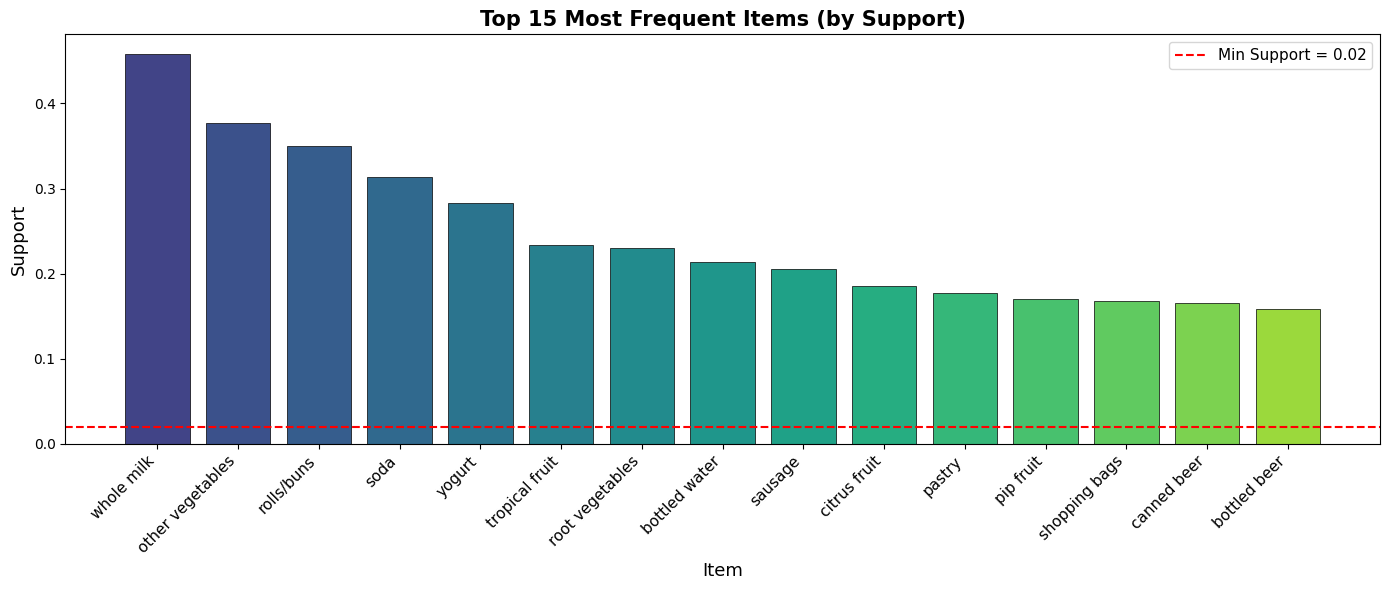

Bar chart saved.


In [13]:
# Top 15 frequent single itemsets
single_items = frequent_itemsets[frequent_itemsets['length'] == 1].copy()
single_items['item'] = single_items['itemsets'].apply(lambda x: list(x)[0])
single_items = single_items.sort_values('support', ascending=False).head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(single_items['item'], single_items['support'],
               color=plt.cm.viridis(np.linspace(0.2, 0.85, 15)), edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.xlabel('Item', fontsize=13)
plt.ylabel('Support', fontsize=13)
plt.title('Top 15 Most Frequent Items (by Support)', fontsize=15, fontweight='bold')
plt.axhline(y=MIN_SUPPORT, color='red', linestyle='--', label=f'Min Support = {MIN_SUPPORT}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('frequent_itemsets_bar.png', dpi=150)
plt.show()
print("Bar chart saved.")

### 2. Support vs Confidence Plot

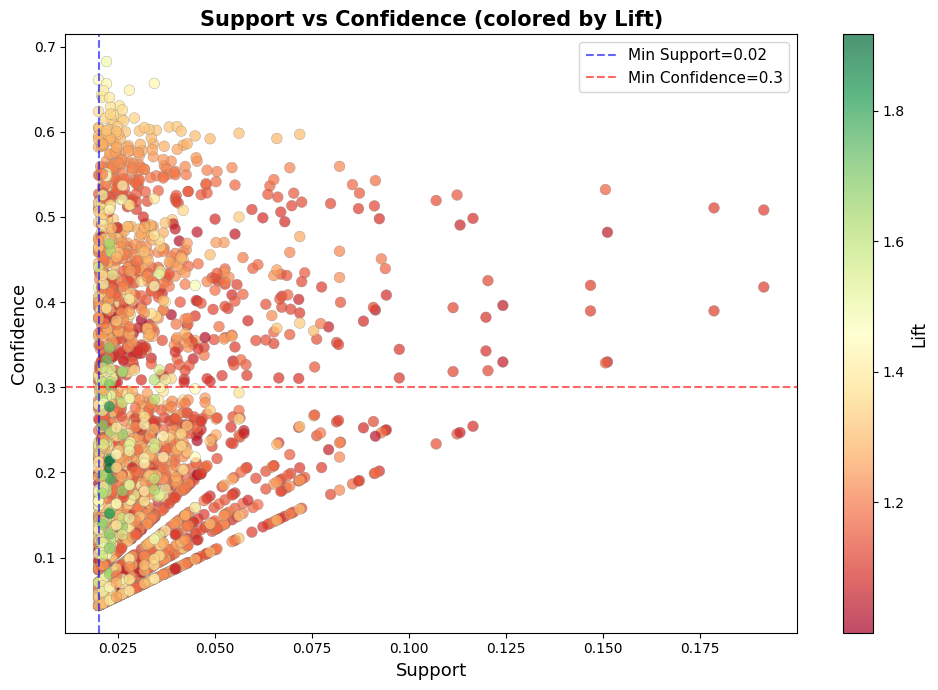

Scatter plot saved.


In [14]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='RdYlGn',
    alpha=0.7,
    s=60,
    edgecolors='grey',
    linewidths=0.3
)
cbar = plt.colorbar(scatter)
cbar.set_label('Lift', fontsize=12)
plt.axvline(x=MIN_SUPPORT, color='blue', linestyle='--', alpha=0.6, label=f'Min Support={MIN_SUPPORT}')
plt.axhline(y=MIN_CONFIDENCE, color='red', linestyle='--', alpha=0.6, label=f'Min Confidence={MIN_CONFIDENCE}')
plt.xlabel('Support', fontsize=13)
plt.ylabel('Confidence', fontsize=13)
plt.title('Support vs Confidence (colored by Lift)', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('support_vs_confidence.png', dpi=150)
plt.show()
print("Scatter plot saved.")

### 3. Effect of Support Threshold on Number of Itemsets

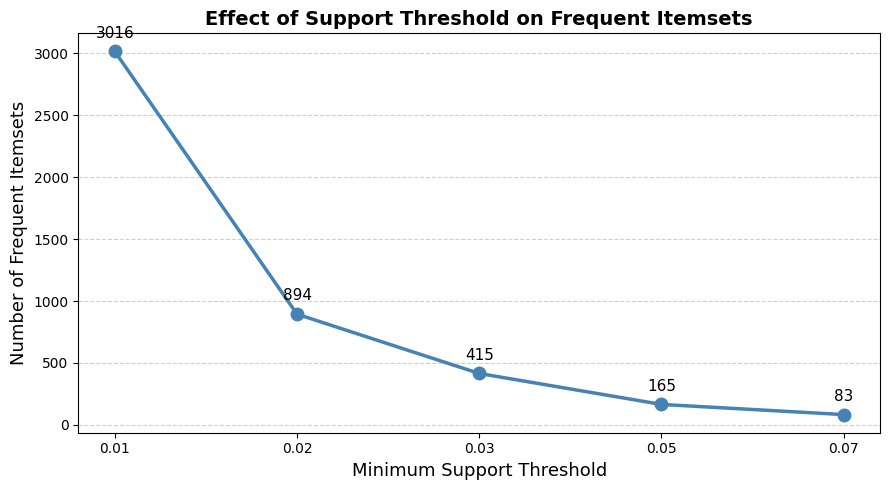

Threshold effect chart saved.


In [15]:
plt.figure(figsize=(9, 5))
plt.plot([str(s) for s in support_thresholds], itemset_counts,
         marker='o', color='steelblue', linewidth=2.5, markersize=9)
for x, y in zip([str(s) for s in support_thresholds], itemset_counts):
    plt.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
plt.xlabel('Minimum Support Threshold', fontsize=13)
plt.ylabel('Number of Frequent Itemsets', fontsize=13)
plt.title('Effect of Support Threshold on Frequent Itemsets', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('support_threshold_effect.png', dpi=150)
plt.show()
print("Threshold effect chart saved.")

### 4. Network Graph of Association Rules

NameError: name 'G' is not defined

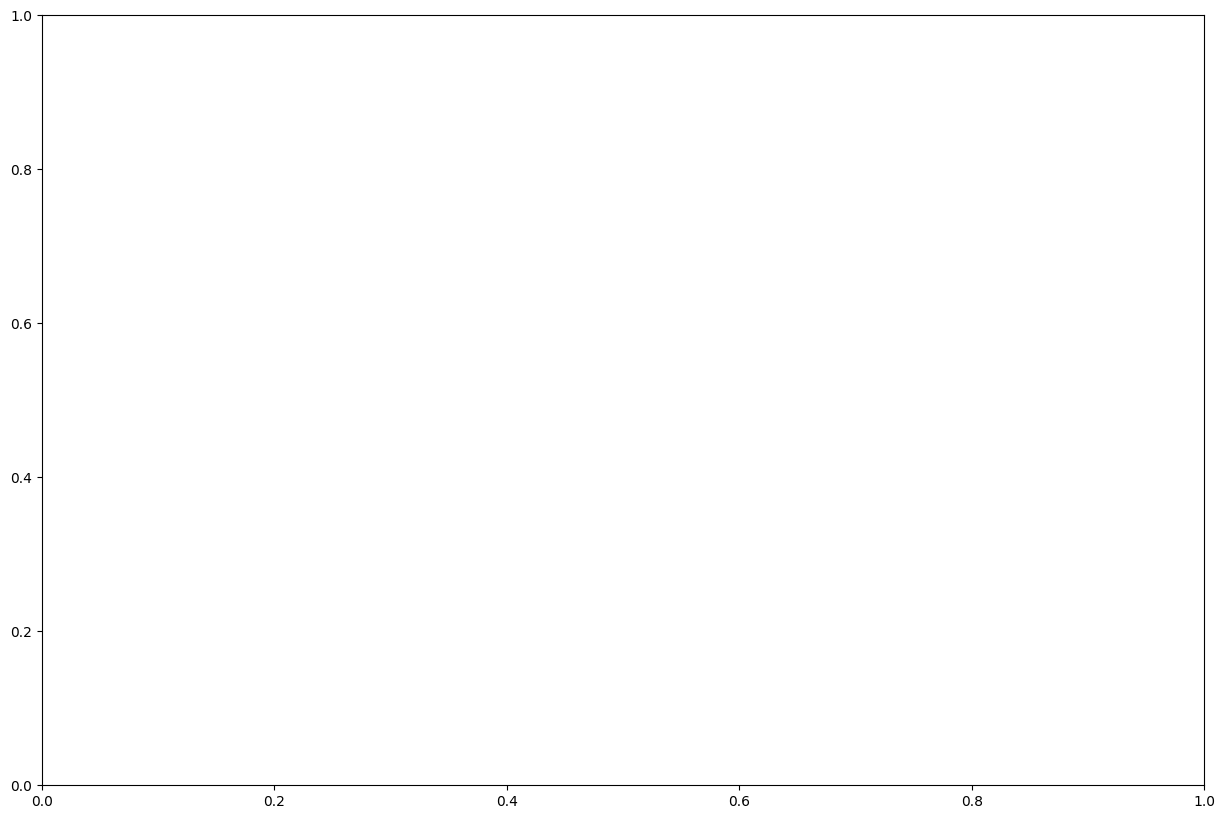

In [17]:
fig, ax = plt.subplots(figsize=(15, 10))

pos = nx.spring_layout(G, seed=42, k=2)

node_size = [800 + 400 * G.degree(n) for n in G.nodes()]
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_size,
                       node_color='skyblue', alpha=0.9,
                       edgecolors='steelblue', linewidths=1.5, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

edges = nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Oranges,
    width=2.5,
    arrows=True,
    arrowsize=20,
    connectionstyle='arc3,rad=0.1',
    ax=ax
)

# Create proper mappable
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.Oranges,
    norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights))
)
sm.set_array([])

# ✅ FIX: attach to axis
plt.colorbar(sm, ax=ax, label='Lift', shrink=0.7)

ax.set_title('Association Rules Network Graph (Top 20 Rules by Lift)',
             fontsize=15, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('association_rules_network.png', dpi=150)
plt.show()

### 5. Heatmap: Top Item Co-occurrence

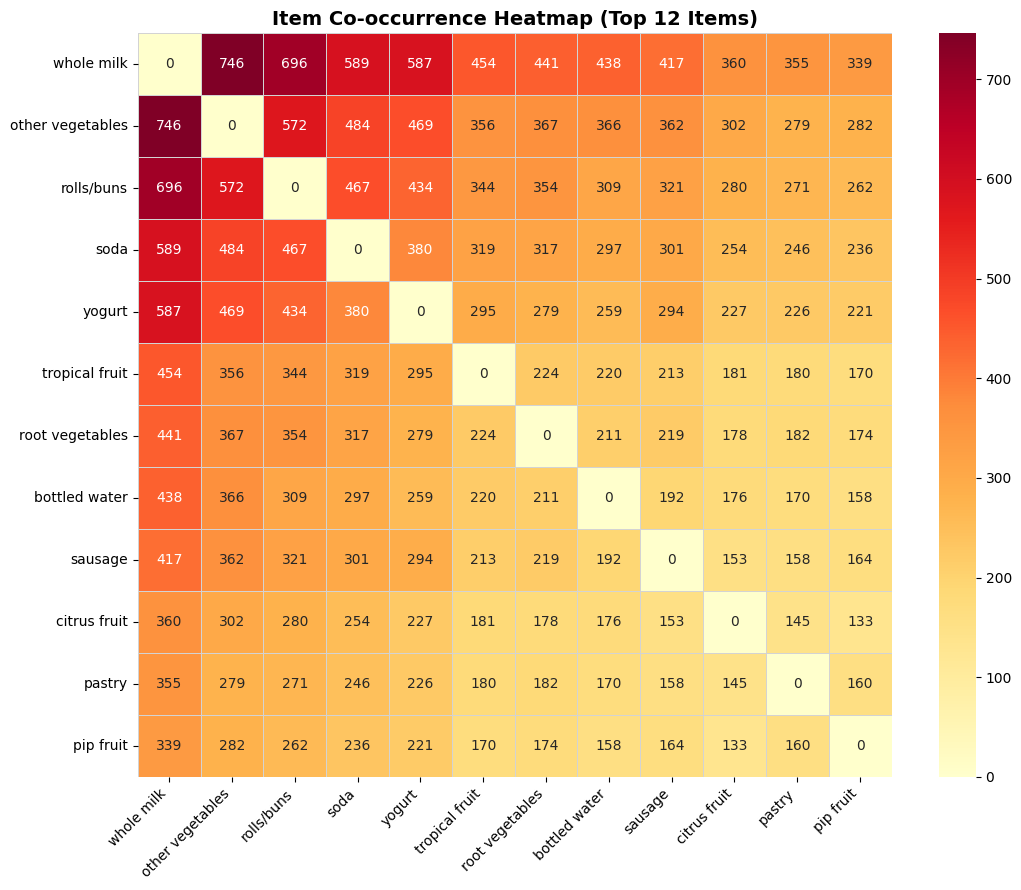

Heatmap saved.


In [ ]:
top_items = single_items['item'].head(12).tolist()
df_top = df_encoded[top_items]

cooc = df_top.astype(int).T @ df_top.astype(int)

# Safe diagonal removal
cooc_values = cooc.to_numpy(copy=True)
np.fill_diagonal(cooc_values, 0)
cooc = pd.DataFrame(cooc_values, index=cooc.index, columns=cooc.columns)

plt.figure(figsize=(11, 9))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='lightgray')

plt.title('Item Co-occurrence Heatmap (Top 12 Items)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150)
plt.show()

print("Heatmap saved.")

## Evaluation Metrics Summary

In [ ]:
print("=" * 60)
print("EVALUATION METRICS SUMMARY")
print("=" * 60)
print(f"Total Transactions        : {len(basket)}")
print(f"Unique Items              : {df['itemDescription'].nunique()}")
print(f"Min Support Used          : {MIN_SUPPORT}")
print(f"Frequent Itemsets Found   : {len(frequent_itemsets)}")
print(f"Total Rules Generated     : {len(rules)}")
print(f"Strong Rules (conf>={MIN_CONFIDENCE}, lift>={MIN_LIFT}): {len(strong_rules)}")
print()
print("Rules Statistics:")
print(rules[['support','confidence','lift']].describe().round(4))

EVALUATION METRICS SUMMARY
Total Transactions        : 3898
Unique Items              : 167
Min Support Used          : 0.02
Frequent Itemsets Found   : 894
Total Rules Generated     : 2956
Strong Rules (conf>=0.3, lift>=1.2): 462

Rules Statistics:
         support  confidence       lift
count  2956.0000   2956.0000  2956.0000
mean      0.0314      0.2364     1.2362
std       0.0162      0.1531     0.1248
min       0.0200      0.0437     1.0001
25%       0.0223      0.1108     1.1442
50%       0.0259      0.1907     1.2179
75%       0.0339      0.3472     1.2994
max       0.1914      0.6825     1.9169
